In [1]:
import math
import numpy as np
from jax import Array
from jax import numpy as jnp
from jax import scipy as jsp
import matplotlib.pyplot as plt

from blueprint.qubits import TunableTransmon

In [2]:
# units
kHz, MHz, GHz = 1e-6, 1e-3, 1
ns, us, ms, s = 1 * 2 * math.pi, 1e3 * 2 * math.pi, 1e6 * 2 * math.pi, 1e9 * 2 * math.pi

In [3]:
label = "Q1"
charging_energy = 0.17874386390652913 * GHz
josephson_energy = 28.045385714769342 * GHz
asymmetry = 0.617379794210013
charge_cutoff = 100
offset_charge = 0.0
ext_flux = 0.0
dim = 3

In [4]:
def flux_pulse(applied_flux: float) -> float:
    return applied_flux

External flux scan 

In [5]:
num_points = 201
num_levels = 10
max_flux = 2 * math.pi
diagonalize = True

fluxes = np.linspace(-max_flux, max_flux, num_points)

result = np.zeros((num_points, num_levels))
for idx, flux in enumerate(fluxes):
    fluxed_transmon = TunableTransmon(
        label=label,
        charging_energy=charging_energy,
        josephson_energy=josephson_energy,
        offset_charge=offset_charge,
        ext_flux=flux,
        asymmetry=asymmetry,
        charge_cutoff=charge_cutoff,
    )
    if diagonalize:
        fluxed_transmon.diagonalize(num_levels)

    energies = fluxed_transmon.get_eigenvalues()
    result[idx] = energies[:num_levels]

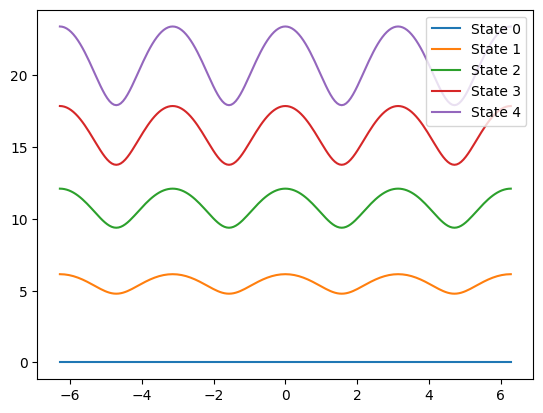

In [6]:
fig, ax = plt.subplots()

for state in range(5):
    ax.plot(fluxes, result[:, state], label=f"State {state}")

ax.legend()
plt.show()

scan with drive

In [11]:
num_points = 201
num_levels = 10
max_flux = math.pi
diagonalize = False

fluxes = np.linspace(-max_flux, max_flux, num_points)

transmon = TunableTransmon(
    label=label,
    charging_energy=charging_energy,
    josephson_energy=josephson_energy,
    offset_charge=offset_charge,
    ext_flux=ext_flux,
    asymmetry=asymmetry,
    charge_cutoff=charge_cutoff,
)

if diagonalize:
    transmon.diagonalize(num_levels)

static_hamiltonian = transmon.get_hamiltonian()

transmon.add_flux_drive(label="drive", flux_pulse=flux_pulse)
result = np.zeros((num_points, num_levels))

for idx, flux in enumerate(fluxes):
    drive_hamiltonian = transmon.get_drive_hamiltonian(applied_flux=flux)
    hamiltonian = static_hamiltonian + drive_hamiltonian
    energies = jsp.linalg.eigh(hamiltonian, eigvals_only=True)
    norm_energies = energies - energies[0]
    result[idx] = norm_energies[:num_levels]

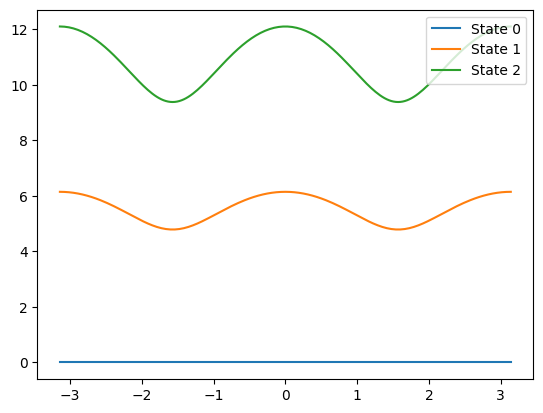

In [12]:
fig, ax = plt.subplots()

for state in range(3):
    ax.plot(fluxes, result[:, state], label=f"State {state}")
    
ax.legend()
plt.show()

In [39]:
num_points = 201
num_levels = 3
max_flux = math.pi
diagonalize = True

fluxes = np.linspace(-max_flux, max_flux, num_points)

transmon = TunableTransmon(
    label=label,
    charging_energy=charging_energy,
    josephson_energy=josephson_energy,
    offset_charge=offset_charge,
    ext_flux=ext_flux,
    asymmetry=asymmetry,
    charge_cutoff=charge_cutoff,
)

if diagonalize:
    transmon.diagonalize(num_levels)

static_hamiltonian = transmon.get_hamiltonian()

transmon.add_flux_drive(label="drive", flux_pulse=flux_pulse)
result2 = np.zeros((num_points, num_levels))

for idx, flux in enumerate(fluxes):
    drive_hamiltonian = transmon.get_drive_hamiltonian(applied_flux=flux)
    hamiltonian = static_hamiltonian + drive_hamiltonian
    energies = jsp.linalg.eigh(hamiltonian, eigvals_only=True)
    norm_energies = energies - energies[0]
    result2[idx] = norm_energies[:num_levels]

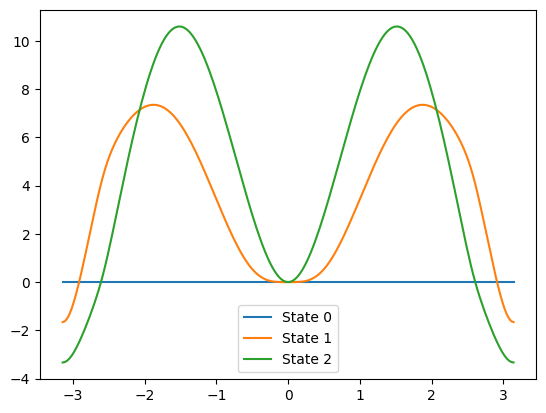

In [40]:
fig, ax = plt.subplots()

for state in range(3):
    ax.plot(fluxes, result2[:, state] - result[:, state], label=f"State {state}")

#ax.set_ylim(0, 0.10)
#ax.set_xlim(-1, 1)
ax.legend()
plt.show()

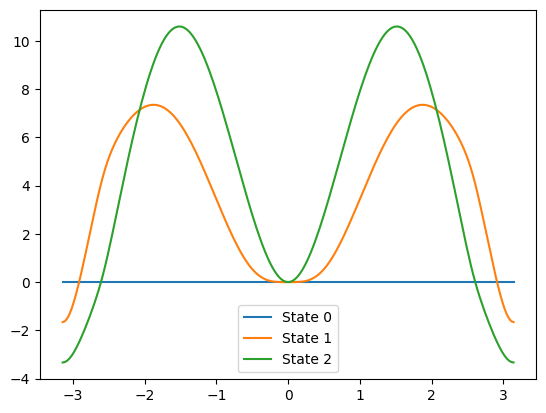

In [29]:
fig, ax = plt.subplots()

for state in range(3):
    ax.plot(fluxes, result2[:, state] - result[:, state], label=f"State {state}")

#ax.set_ylim(0, 0.10)
#ax.set_xlim(-1, 1)
ax.legend()
plt.show()

In [54]:
from blueprint.pulses.flux_pulses import net_zero_transition_flux_pulse

In [55]:
num_points = 201
num_levels = 10
times = np.linspace(0, 100, num_points)

transmon = TunableTransmon(
    label=label,
    charging_energy=charging_energy,
    josephson_energy=josephson_energy,
    offset_charge=offset_charge,
    ext_flux=ext_flux,
    asymmetry=asymmetry,
    charge_cutoff=charge_cutoff,
)

static_hamiltonian = transmon.get_hamiltonian()
transmon.add_flux_drive(label="drive", flux_pulse=net_zero_transition_flux_pulse)

transmon.drives["drive"].set_params(
    hold_first_voltage=-0.255,
    transition_voltage=0.0,
    half_hold_time=65.15 * 0.5,
    transition_time=2.414131062723352,
    buffer_start=1.9349107142857144e1,
    buffer_end=1.9349107142857144e1,
    flux_per_volt=3.1372549019607843,
    gaussian_filter_sigma=0.5,
)

result = np.zeros((num_points, num_levels))
for idx, time in enumerate(times):
    drive_hamiltonian = transmon.get_drive_hamiltonian(t=time)
    hamiltonian = static_hamiltonian + drive_hamiltonian
    energies = jsp.linalg.eigh(hamiltonian, eigvals_only=True)
    norm_energies = energies - energies[0]
    result[idx] = norm_energies[:num_levels]

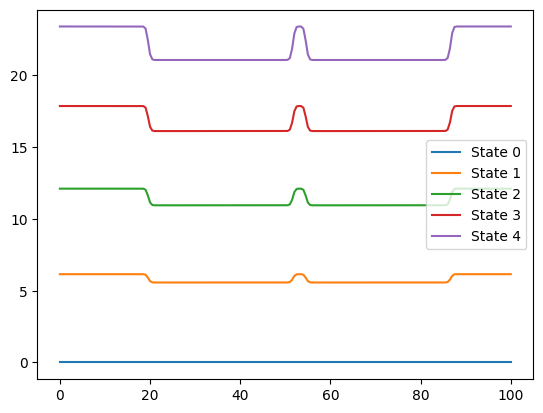

In [56]:
fig, ax = plt.subplots()

for state in range(5):
    ax.plot(times, result[:, state], label=f"State {state}")

ax.legend()
plt.show()

In [30]:
num_points = 201
num_levels = 10
times = np.linspace(0, 100, num_points)

transmon = TunableTransmon(
    label=label,
    charging_energy=charging_energy,
    josephson_energy=josephson_energy,
    offset_charge=offset_charge,
    ext_flux=ext_flux,
    asymmetry=asymmetry,
    charge_cutoff=charge_cutoff,
)

static_hamiltonian = transmon.get_hamiltonian()
transmon.add_flux_drive(label="drive", flux_pulse=net_zero_transition_flux_pulse)

transmon.drives["drive"].set_params(
    hold_first_voltage=-0.255,
    transition_voltage=0.0,
    half_hold_time=65.15 * 0.5,
    transition_time=2.414131062723352,
    buffer_start=1.9349107142857144e1,
    buffer_end=1.9349107142857144e1,
    flux_per_volt=3.1372549019607843,
    gaussian_filter_sigma=0.5,
)

result = np.zeros((num_points, num_levels))
for idx, time in enumerate(times):
    drive_hamiltonian = jnp.zeros(hamiltonian.shape)
    for prefactor, op in transmon.get_drive_hamiltonian_terms():
        eval_prefactor = prefactor(t=time)
        drive_hamiltonian = drive_hamiltonian + eval_prefactor * op
        
    hamiltonian = static_hamiltonian + drive_hamiltonian
    energies = jsp.linalg.eigh(hamiltonian, eigvals_only=True)
    norm_energies = energies - energies[0]
    result[idx] = norm_energies[:num_levels]

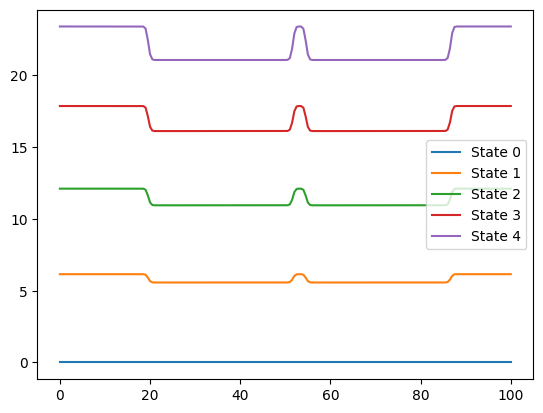

In [31]:
fig, ax = plt.subplots()

for state in range(5):
    ax.plot(times, result[:, state], label=f"State {state}")

ax.legend()
plt.show()

In [32]:
import dynamiqs as dq

/Users/varb2323/Projects/blueprint/.venv/lib/python3.12/site-packages/qutip/__init__.py:71: UserWarning: Runtime cython compilation does not work on Python 3.12.
  warnings.warn(


In [33]:
num_points = 201
num_levels = 10
times = np.linspace(0, 100, num_points)

transmon = TunableTransmon(
    label=label,
    charging_energy=charging_energy,
    josephson_energy=josephson_energy,
    offset_charge=offset_charge,
    ext_flux=ext_flux,
    asymmetry=asymmetry,
    charge_cutoff=charge_cutoff,
)

static_hamiltonian = transmon.get_hamiltonian()
dq_hamiltonian = dq.constant(static_hamiltonian)

transmon.add_flux_drive(label="drive", flux_pulse=net_zero_transition_flux_pulse)

transmon.drives["drive"].set_params(
    hold_first_voltage=-0.255,
    transition_voltage=0.0,
    half_hold_time=65.15 * 0.5,
    transition_time=2.414131062723352,
    buffer_start=1.9349107142857144e1,
    buffer_end=1.9349107142857144e1,
    flux_per_volt=3.1372549019607843,
    gaussian_filter_sigma=0.5,
)

for prefactor, op in transmon.get_drive_hamiltonian_terms():
        print(prefactor, op)
        def dq_func(t: float) -> Array:
              return prefactor(t=t)
        dq_term = dq.modulated(dq_func, op)
        dq_hamiltonian += dq_term

result = np.zeros((num_points, num_levels))
for idx, time in enumerate(times):
    hamiltonian = dq_hamiltonian(time)
    energies = jsp.linalg.eigh(hamiltonian, eigvals_only=True)
    norm_energies = energies - energies[0]
    result[idx] = norm_energies[:num_levels]


<blueprint.base.terms.TimeDependentTerm object at 0x15e46e060> [[0. +0.j 0.5+0.j 0. +0.j ... 0. +0.j 0. +0.j 0. +0.j]
 [0.5+0.j 0. +0.j 0.5+0.j ... 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0.5+0.j 0. +0.j ... 0. +0.j 0. +0.j 0. +0.j]
 ...
 [0. +0.j 0. +0.j 0. +0.j ... 0. +0.j 0.5+0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j ... 0.5+0.j 0. +0.j 0.5+0.j]
 [0. +0.j 0. +0.j 0. +0.j ... 0. +0.j 0.5+0.j 0. +0.j]]
<blueprint.base.terms.TimeDependentTerm object at 0x15d8f75c0> [[0.+0.j  0.+0.5j 0.+0.j  ... 0.+0.j  0.+0.j  0.+0.j ]
 [0.-0.5j 0.+0.j  0.+0.5j ... 0.+0.j  0.+0.j  0.+0.j ]
 [0.+0.j  0.-0.5j 0.+0.j  ... 0.+0.j  0.+0.j  0.+0.j ]
 ...
 [0.+0.j  0.+0.j  0.+0.j  ... 0.+0.j  0.+0.5j 0.+0.j ]
 [0.+0.j  0.+0.j  0.+0.j  ... 0.-0.5j 0.+0.j  0.+0.5j]
 [0.+0.j  0.+0.j  0.+0.j  ... 0.+0.j  0.-0.5j 0.+0.j ]]


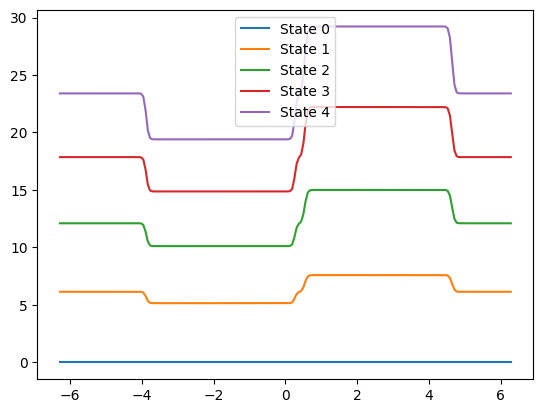

In [26]:
fig, ax = plt.subplots()

for state in range(5):
    ax.plot(fluxes, result[:, state], label=f"State {state}")

ax.legend()
plt.show()

In [65]:
dim = 3

transmon = TunableTransmon(
    label=label,
    charging_energy=charging_energy,
    josephson_energy=josephson_energy,
    offset_charge=offset_charge,
    ext_flux=ext_flux,
    asymmetry=asymmetry,
    charge_cutoff=charge_cutoff,
)


_hamiltonian = transmon._get_hamiltonian()
eig_vals, eig_vecs = jsp.linalg.eigh(_hamiltonian)
trunc_vecs = eig_vecs[:, :dim]

cur_hamil = jnp.conj(trunc_vecs.T) @ _hamiltonian @ trunc_vecs
alt_hamil = trunc_vecs.T @ _hamiltonian @ jnp.conj(trunc_vecs)

In [67]:
cur_hamil - cur_hamil[0] * jnp.identity(dim)

Array([[ 0.0000000e+00+0.j, -3.1262846e-06+0.j, -1.7849253e-07+0.j],
       [-1.9855611e-06+0.j, -1.8775833e+01+0.j, -2.4217920e-06+0.j],
       [-1.4414290e-07+0.j, -2.3609498e-06+0.j, -1.2819120e+01+0.j]],      dtype=complex64)

In [68]:
alt_hamil - alt_hamil[0] * jnp.identity(dim)

Array([[ 0.0000000e+00+0.j, -3.1262846e-06+0.j, -1.7849253e-07+0.j],
       [-1.9855611e-06+0.j, -1.8775833e+01+0.j, -2.4217920e-06+0.j],
       [-1.4414290e-07+0.j, -2.3609498e-06+0.j, -1.2819120e+01+0.j]],      dtype=complex64)